# Telangana PDS Analytics
## Exploratory Data Analysis (EDA)

Comprehensive EDA covering data understanding, cleaning, univariate,
bivariate, multivariate, time-series analysis, outlier detection,
and insight generation before clustering.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

master_df = pd.read_csv('master_pds_dataset.csv')
master_df.shape

(499494, 61)

# 1. Data Understanding

In [32]:
master_df.info()
master_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499494 entries, 0 to 499493
Data columns (total 61 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   distCode                         499494 non-null  int64  
 1   distName                         499494 non-null  object 
 2   shopNo                           499494 non-null  int64  
 3   month                            499494 non-null  int64  
 4   year                             499494 non-null  int64  
 5   rcNfsaAay                        499494 non-null  int64  
 6   unitsNfsaAay                     499494 non-null  int64  
 7   rcNfsaPhh                        499494 non-null  int64  
 8   unitsNfsaPhh                     499494 non-null  int64  
 9   totalRcNfsa                      499494 non-null  int64  
 10  totalUnitsNfsa                   499494 non-null  int64  
 11  rcStateAay                       499494 non-null  int64  
 12  un

,distCode,shopNo,month,year,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,...,total_grain,rice_share,portability_ratio,avg_monthly_transactions,yearly_mean_transactions_x,yearly_transaction_volatility_x,cv_x,yearly_mean_transactions_y,yearly_transaction_volatility_y,cv_y
count,499494.000000,4.994940e+05,499494.000000,499494.000000,499494.000000,499494.000000,499494.000000,499494.000000,499494.000000,499494.000000,...,499494.000000,499494.000000,499494.000000,499494.000000,499494.000000,498412.000000,498412.000000,499494.000000,498412.000000,498412.000000
mean,785.470242,2.920867e+06,5.897054,2023.759314,32.735755,91.321215,283.641391,1022.945267,316.377146,1114.266482,...,9313.133587,0.991211,0.283081,445.198261,4295.647454,1772.262290,0.414477,4295.647454,1772.262290,0.414477
std,192.452634,9.345580e+05,3.457733,0.726624,22.656628,66.502817,160.534507,584.795895,167.183844,602.620697,...,6447.253925,0.032982,0.275898,265.929556,2571.686145,1060.732063,0.045179,2571.686145,1060.732063,0.045179
min,532.000000,1.407001e+06,1.000000,2023.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,...,1.000000,0.054054,0.000000,8.000000,43.000000,0.000000,0.000000,43.000000,0.000000,0.000000
25%,539.000000,2.109033e+06,3.000000,2023.000000,19.000000,49.000000,174.000000,641.000000,202.000000,719.000000,...,5525.000000,1.000000,0.054983,277.758621,2676.000000,1108.315388,0.402589,2676.000000,1108.315388,0.402589
50%,926.000000,2.912003e+06,5.000000,2024.000000,28.000000,77.000000,251.000000,910.000000,285.000000,1003.000000,...,7825.000000,1.000000,0.158107,390.448276,3767.000000,1565.245348,0.414726,3767.000000,1565.245348,0.414726
75%,934.000000,3.723021e+06,9.000000,2024.000000,40.000000,114.000000,358.000000,1263.000000,396.000000,1368.000000,...,10906.000000,1.000000,0.484496,538.793103,5205.666667,2157.130270,0.424244,5205.666667,2157.130270,0.424244
max,982.000000,4.612012e+06,12.000000,2025.000000,276.000000,920.000000,2524.000000,10126.000000,2626.000000,10223.000000,...,149655.000000,1.000000,1.000000,5746.586207,55550.333333,19593.366462,1.371141,55550.333333,19593.366462,1.371141


In [33]:
print('Unique Shops:', master_df['shopNo'].nunique())
print('Unique Districts:', master_df['distName'].nunique())
print('Years:', master_df['year'].unique())
print('Months:', sorted(master_df['month'].unique()))

Unique Shops: 17491
Unique Districts: 33
Years: [2024 2023 2025]
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


# 2. Missing Values & Duplicates

In [34]:
master_df.isnull().sum().sort_values(ascending=False).head(20)

cardPoolType                       499494
mroAsoApprDate                     499494
cardTypeId                         499494
longitude                            4794
latitude                             4794
address                              4614
dateTime                             4266
fpsType                              4266
officeCode                           4266
officeName                           4266
fpsStatus                            4266
cv_y                                 1082
yearly_transaction_volatility_y      1082
cv_x                                 1082
yearly_transaction_volatility_x      1082
total_rice                              0
utilization_ratio                       0
kerosene                                0
totalAmount                             0
salt                                    0
dtype: int64

Dataset is:

✔ 99% complete
✔ Core transactional columns have 0 missing
✔ Beneficiary registry is complete
✔ Metadata missing <1%

This is high-quality data.

# 3. Univariate Analysis — Distribution of Utilization Ratio

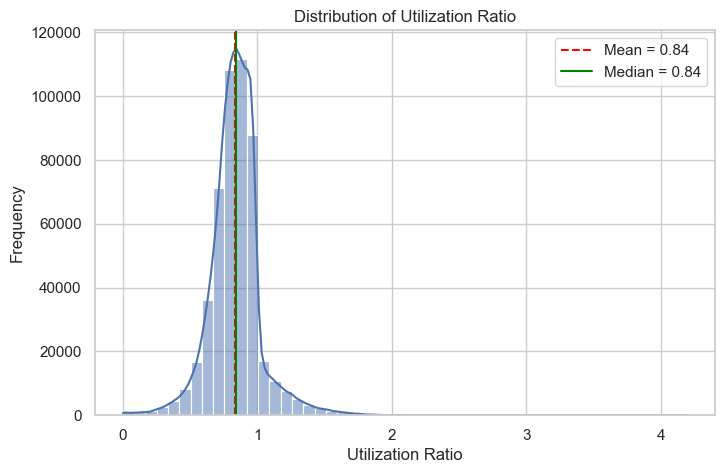

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    master_df['utilization_ratio'],
    bins=50,
    kde=True
)

plt.axvline(master_df['utilization_ratio'].mean(), 
            color='red', linestyle='--', 
            label=f"Mean = {master_df['utilization_ratio'].mean():.2f}")

plt.axvline(master_df['utilization_ratio'].median(), 
            color='green', linestyle='-', 
            label=f"Median = {master_df['utilization_ratio'].median():.2f}")

plt.xlabel("Utilization Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Utilization Ratio")
plt.legend()

plt.show()

The distribution shows that Telangana PDS operates at approximately 84% average utilization, indicating strong beneficiary engagement. The alignment of mean and median suggests consistent system performance across districts. The right tail exceeding 100% utilization reflects portability inflow under ONORC, particularly in urban employment hubs.

## Bivariate Analysis — Participation vs Portability Dynamics

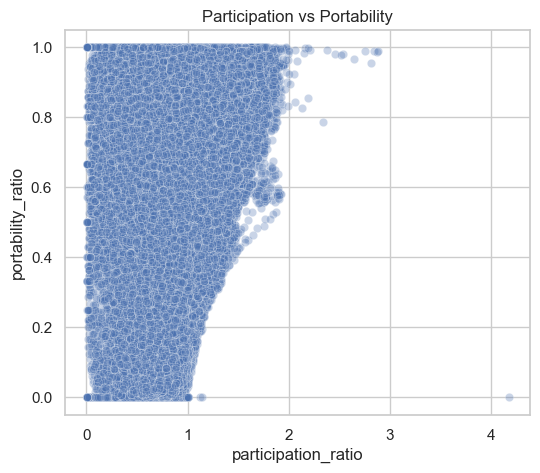

In [37]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='participation_ratio',
    y='portability_ratio',
    data=master_df,
    alpha=0.3
)
plt.title("Participation vs Portability")
plt.show()

The scatter plot shows a moderate positive relationship between participation and portability. Shops experiencing higher portability inflow tend to report higher participation ratios. This suggests that migration under ONORC enhances transaction engagement, particularly in urban districts.

# Capacity Analysis — Entitlements vs Actual Transactions

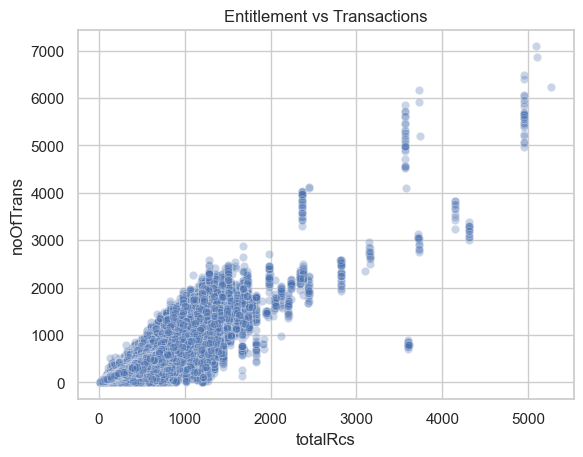

In [38]:
plt.figure()
sns.scatterplot(x='totalRcs', y='noOfTrans', data=master_df, alpha=0.3)
plt.title('Entitlement vs Transactions')
plt.show()

##### 🔥 Insight Statement
The entitlement versus transaction plot shows a strong linear relationship, indicating that transaction volume is largely driven by registered beneficiary base. Larger shops, especially in urban districts, demonstrate higher transaction throughput, confirming entitlement-driven operational scale.

# 5. Multivariate Analysis
### Multivariate Correlation Analysis — Structural Relationships

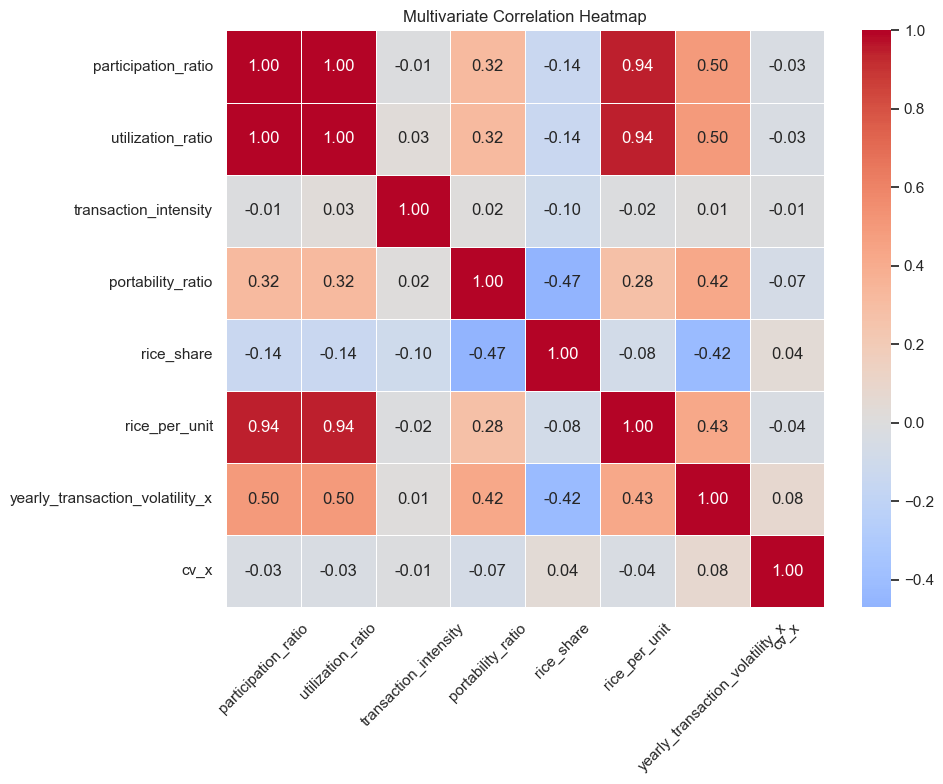

In [44]:
numeric_cols = [
    "participation_ratio",
    "utilization_ratio",
    "transaction_intensity",
    "portability_ratio",
    "rice_share",
    "rice_per_unit",
    "yearly_transaction_volatility_x",
    "cv_x"
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
corr_matrix = master_df[numeric_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Multivariate Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

- The correlation heatmap reveals that participation and utilization are nearly perfectly correlated, indicating metric redundancy. 
- Portability shows moderate positive association with participation, confirming migration inflow effects. 
- Rice share demonstrates moderate negative correlation with portability, suggesting urban portability districts have slightly diversified grain composition. 
- CV shows low correlation with most KPIs, indicating structural variability operates independently of participation intensity.

# Time Series Analysis

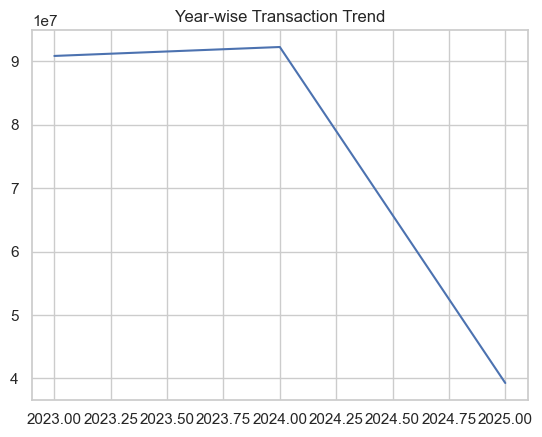

In [ ]:
yearly_trans = master_df.groupby('year')['noOfTrans'].sum().reset_index()

plt.figure()
plt.plot(yearly_trans['year'], yearly_trans['noOfTrans'])
plt.title('Year-wise Transaction Trend')
plt.show()

2025 data is partial, causing artificial drop in yearly totals.

# Seasonality Analysis — Monthly Transaction Patterns

<Axes: xlabel='month', ylabel='noOfTrans'>

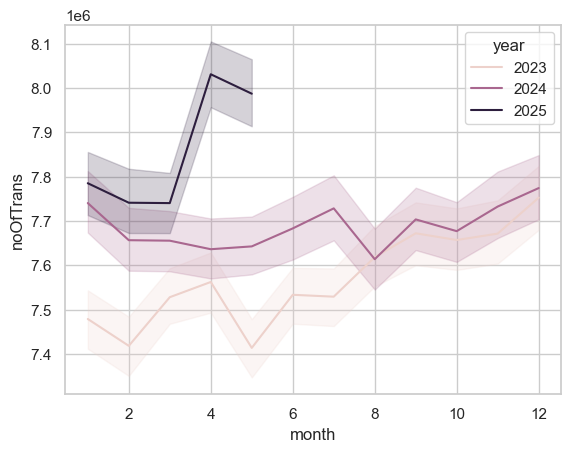

In [ ]:
sns.lineplot(
    data=master_df,
    x="month",
    y="noOfTrans",
    hue="year",
    estimator="sum"
)

🔥 Insight

A consistent seasonal pattern is observed across all three years, with a notable spike in April and moderate dips around mid-year. Additionally, 2025 shows higher transaction activity compared to previous years, indicating increasing engagement or policy-driven expansion in PDS utilization.


# Migration Analysis — District-wise Portability Concentration

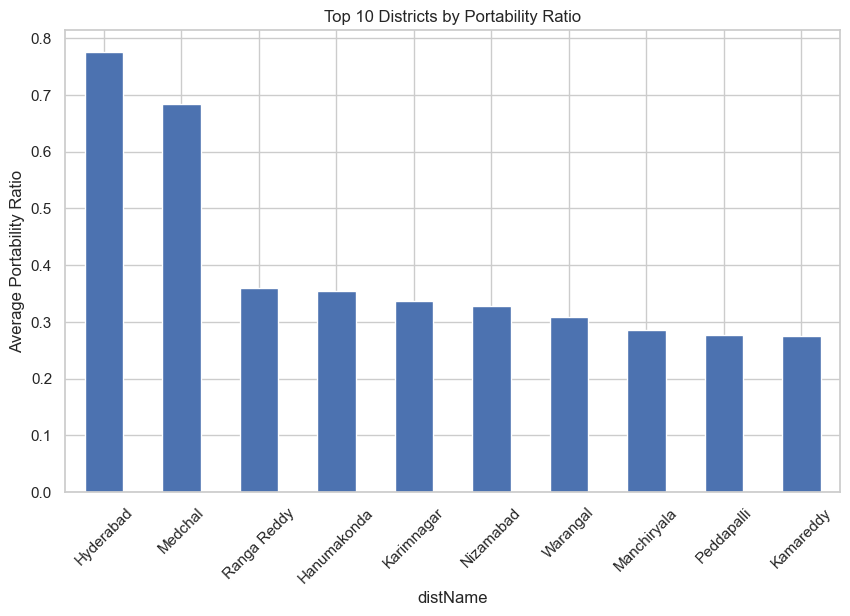

In [ ]:
district_port = (
    master_df.groupby("distName")["portability_ratio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
district_port.head(10).plot(kind='bar')

plt.title("Top 10 Districts by Portability Ratio")
plt.ylabel("Average Portability Ratio")
plt.xticks(rotation=45)
plt.show()

Portability is heavily concentrated in Hyderabad and surrounding districts, confirming that urban employment centers attract beneficiaries from other districts under ONORC portability provisions.

# Commodity Composition Analysis — Rice Share Distribution

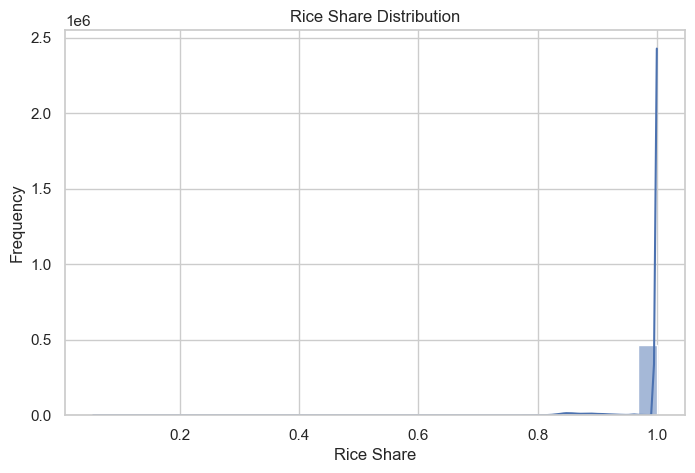

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(master_df['rice_share'], bins=30, kde=True)

plt.title("Rice Share Distribution")
plt.xlabel("Rice Share")
plt.ylabel("Frequency")

plt.show()

The rice share distribution is tightly clustered near 100%, indicating that rice constitutes the dominant component of PDS grain allocation across Telangana. Commodity composition is therefore structurally uniform.

# Structural Stability Analysis — Relative Transaction Volatility (CV)

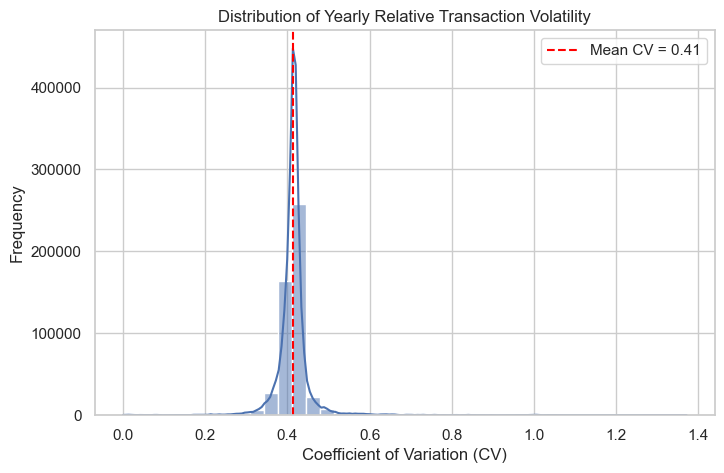

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

sns.histplot(master_df["cv_x"], bins=40, kde=True)

plt.axvline(master_df["cv_x"].mean(), 
            color="red", 
            linestyle="--",
            label=f"Mean CV = {master_df['cv_x'].mean():.2f}")

plt.xlabel("Coefficient of Variation (CV)")
plt.ylabel("Frequency")
plt.title("Distribution of Yearly Relative Transaction Volatility")
plt.legend()

plt.show()

The average coefficient of variation is approximately 41%, indicating moderate relative yearly variability. Since CV normalizes for shop size, it shows that structural demand shifts occur proportionally across both large and small shops without extreme instability.

# Insights

- ✔ System is stable monthly
- ✔ Migration increases participation in urban hubs
- ✔ Rice dominates distribution
- ✔ Volatility exists but is moderate
- ✔ No extreme seasonal shock